# Preprocesamiento para Autoencoder - Dataset Multivariado H2V

Preparar los datos imputados para el entrenamiento del autoencoder.

## Input
- Datasets: `data/autoencoder_stack/autoencoder_stack_{ssp}_test_imputed.nc`
- Variables: 23 (22 originales + is_land)
- Grid: 1,008 celdas (24×42)
- Periodo: 86 años (2015-2100) para variables climáticas

## Output
- Tensores normalizados para train/val/test
- Metadatos de normalización (scalers)
- Máscaras espaciales guardadas
- Dataset consolidado listo para autoencoder

## Imports y Configuración

In [5]:
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from copy import deepcopy
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.model_selection import train_test_split
import pickle

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (16, 10)
plt.rcParams['font.size'] = 10

## Rutas y Parámetros

In [6]:
BASE_DIR = Path('/home/aninotna/magister/tesis/justh2_pipeline')
DATA_DIR = BASE_DIR / 'data' / 'autoencoder_stack'
OUT_DIR = BASE_DIR / 'data' / 'autoencoder_tensors'
PLOTS_DIR = BASE_DIR / 'plots' / 'autoencoder_prep'
OUT_DIR.mkdir(exist_ok=True, parents=True)
PLOTS_DIR.mkdir(exist_ok=True, parents=True)

MODE = 'full'
SCENARIOS = ['ssp245', 'ssp370', 'ssp585']
REFERENCE_SCENARIO = 'ssp245'

# REDUCCIÓN DE DIMENSIONALIDAD TEMPORAL:
# Calcular solo medias decádicas para un subconjunto de décadas representativas.
# Objetivo: Evitar redundancia temporal y que el espacio latente se organice
# por diferencias de escenario en lugar de perfiles territoriales.
TARGET_DECADES = [2020, 2050, 2080]

CONFIG = {
    'use_mask': 'h2v_viable',
    'temporal_aggregation': 'decadal_stats',
    'train_ratio': 0.70,
    'val_ratio': 0.15,
    'test_ratio': 0.15,
    'random_seed': 42,
    'normalize': True,
    'scaler_type': {
        'continuous': 'standard',
        'fractions': 'minmax',
        'binary': None
    }
}

VAR_NORMALIZATION = {
    # Calliope: producción, costos y capacidades
    'calliope_h2_prod_ton': 'standard',
    'calliope_lcoh_usd_kg': 'standard',
    'calliope_cap_electrolyzer_mw': 'standard',
    'calliope_cap_pv_mw': None,              # Variable constante/categórica
    'calliope_cf_mean': None,                # Ya en [0,1] por definición
    
    # Variables climáticas (base, decadales y variabilidad temporal)
    # NOTA: Las features *_decadal_mean_YYYY y *_std_T se mapearán automáticamente
    #       a su variable base (e.g., climate_tmax_mean_decadal_mean_2020 → climate_tmax_mean)
    'climate_tmax_mean': 'standard',
    'climate_tmin_mean': 'standard',
    'climate_prcptot': 'standard',
    'climate_r10mm': 'standard',
    'climate_rx1day': 'standard',
    'climate_rx5day': 'standard',
    'climate_cdd': 'standard',
    'climate_sdii': 'standard',
    
    # Topografía
    'topo_elevation': 'standard',
    'topo_slope': 'standard',
    
    # Uso de suelo (ya en [0,1])
    'landuse_suitable_pv': 'minmax',
    'landuse_restricted': 'minmax',
    'landuse_agriculture': 'minmax',
    'landuse_urban_infra': 'minmax',
    'landuse_water_glacier': 'minmax',
    
    # Conflictos
    'conflict_density': 'robust',            # Outliers esperados
    'conflict_proximity': None,              # Distancia relativa ya comparable
}

print("Configuración:")
print(f" Escenarios: {', '.join(SCENARIOS)}")
print(f" Referencia: {REFERENCE_SCENARIO}")
print(f" Modo: {MODE}")
print(f" Máscara: {CONFIG['use_mask']}")
print(f" Agregación temporal: {CONFIG['temporal_aggregation']}")
print(f" Décadas target: {TARGET_DECADES} (reducción de redundancia temporal)")
print(f" Split: {CONFIG['train_ratio']:.0%}/{CONFIG['val_ratio']:.0%}/{CONFIG['test_ratio']:.0%}")
print(f"\nEsquema de normalización:")
print(f" StandardScaler: {sum(1 for v in VAR_NORMALIZATION.values() if v == 'standard')} variables")
print(f" MinMaxScaler: {sum(1 for v in VAR_NORMALIZATION.values() if v == 'minmax')} variables")
print(f" RobustScaler: {sum(1 for v in VAR_NORMALIZATION.values() if v == 'robust')} variables")
print(f" Sin normalizar: {sum(1 for v in VAR_NORMALIZATION.values() if v is None)} variables")

Configuración:
 Escenarios: ssp245, ssp370, ssp585
 Referencia: ssp245
 Modo: full
 Máscara: h2v_viable
 Agregación temporal: decadal_stats
 Décadas target: [2020, 2050, 2080] (reducción de redundancia temporal)
 Split: 70%/15%/15%

Esquema de normalización:
 StandardScaler: 13 variables
 MinMaxScaler: 5 variables
 RobustScaler: 1 variables
 Sin normalizar: 3 variables


## Cargar Datasets Imputados

In [7]:
print("Cargando datasets imputados")

datasets = {}

for scenario in SCENARIOS:
    DATA_DIR = BASE_DIR / 'data' / 'autoencoder_stack' / 'autoencoder_preprocessed'
    nc_file = DATA_DIR / f'{scenario}_imputed.nc'    
    if nc_file.exists():
        print(f"\nCargando {scenario.upper()}...")
        ds = xr.open_dataset(nc_file)
        datasets[scenario] = ds
        
        file_size = nc_file.stat().st_size / (1024**2)
        print(f" Archivo: {nc_file.name}")
        print(f" Tamaño: {file_size:.2f} MB")
        print(f" Variables: {len(ds.data_vars)}")
        print(f" Dimensiones: {dict(ds.dims)}")
                
        if 'imputation_applied' in ds.attrs:
            print(f" Imputación: {ds.attrs['imputation_applied']}")
    else:
        print(f"\nNo encontrado: {nc_file.name}")

        print(f"\n{len(datasets)}/{len(SCENARIOS)} escenarios cargados")

if REFERENCE_SCENARIO in datasets:
    ds_ref = datasets[REFERENCE_SCENARIO]
    print(f"\nDataset de referencia: {REFERENCE_SCENARIO.upper()}")
    print(f" Grid: {len(ds_ref.lat)} × {len(ds_ref.lon)} = {len(ds_ref.lat)*len(ds_ref.lon)} celdas")
    if 'year' in ds_ref.dims:
        print(f" Años: {len(ds_ref.year)} ({ds_ref.year.values[0]}-{ds_ref.year.values[-1]})")
else:
    ds_ref = None
    print("\nNo se pudo cargar dataset de referencia")

Cargando datasets imputados

Cargando SSP245...
 Archivo: ssp245_imputed.nc
 Tamaño: 1.38 MB
 Variables: 20
 Dimensiones: {'lat': 24, 'lon': 42, 'year': 86}
 Imputación: True

Cargando SSP370...
 Archivo: ssp370_imputed.nc
 Tamaño: 1.39 MB
 Variables: 20
 Dimensiones: {'lat': 24, 'lon': 42, 'year': 86}
 Imputación: True

Cargando SSP585...
 Archivo: ssp585_imputed.nc
 Tamaño: 1.39 MB
 Variables: 20
 Dimensiones: {'lat': 24, 'lon': 42, 'year': 86}
 Imputación: True

Dataset de referencia: SSP245
 Grid: 24 × 42 = 1008 celdas
 Años: 86 (2015-2100)


## Definir Máscaras Espaciales

Definiendo máscaras espaciales
Variable H2 detectada: calliope_h2_prod_ton
Variable temporal: usando año 2015
Máscara H2V: 0 celdas viables de 1008
Máscara recreada: shape = (24, 42)

Máscara seleccionada: h2v_viable
 Celdas válidas: 0 (0.0%)
 Celdas filtradas: 1008 (100.0%)

Generando visualización de máscaras...
Guardado: /home/aninotna/magister/tesis/justh2_pipeline/plots/autoencoder_prep/spatial_masks_full.png


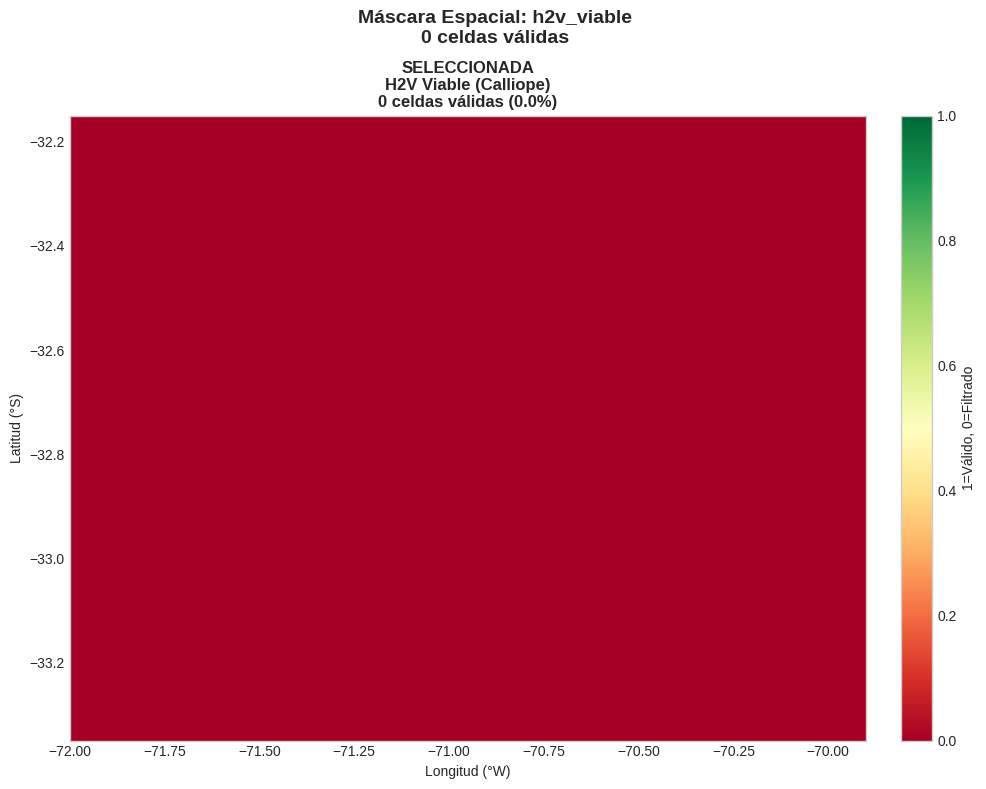

In [8]:
if ds_ref is not None:
    print("Definiendo máscaras espaciales")
    
    masks = {}
    
    # Buscar variables de producción H2 (pueden estar con sufijos decadales)
    h2_vars = [v for v in ds_ref.data_vars if 'calliope_h2_prod_ton' in v]
    
    if not h2_vars:
        print("ADVERTENCIA: No se encontraron variables de producción H2")
        h2v_mask = np.ones((len(ds_ref.lat), len(ds_ref.lon)), dtype=bool)
    else:
        h2v_var_name = h2_vars[0]  # Usar la primera disponible
        print(f"Variable H2 detectada: {h2v_var_name}")
        
        h2v_var = ds_ref[h2v_var_name]
        if 'year' in h2v_var.dims:
            h2v_data = h2v_var.isel(year=0).values
            print(f"Variable temporal: usando año {int(h2v_var.year.values[0])}")
        else:
            h2v_data = h2v_var.values
        
        h2v_mask = ~np.isnan(h2v_data)
        print(f"Máscara H2V: {h2v_mask.sum()} celdas viables de {h2v_mask.size}")
    
    masks['h2v_viable'] = h2v_mask
    print(f"Máscara recreada: shape = {h2v_mask.shape}")
    
    selected_mask_name = CONFIG['use_mask']
    if selected_mask_name == 'h2v_viable':
        selected_mask = masks['h2v_viable']
    elif selected_mask_name == 'land_only':
        selected_mask = masks['land']
    elif selected_mask_name == 'full_grid':
        selected_mask = masks['full_grid']
    else:
        selected_mask = masks['combined']
        selected_mask_name = 'combined'
    
    n_selected = selected_mask.sum()
    
    print(f"\nMáscara seleccionada: {selected_mask_name}")
    print(f" Celdas válidas: {n_selected} ({n_selected/selected_mask.size*100:.1f}%)")
    print(f" Celdas filtradas: {selected_mask.size - n_selected} ({(1-n_selected/selected_mask.size)*100:.1f}%)")
        
    print("\nGenerando visualización de máscaras...")
        
    fig, ax = plt.subplots(1, 1, figsize=(10, 8))
    
    mask_name = 'h2v_viable'
    label = 'H2V Viable (Calliope)'
    
    mask_data = masks[mask_name].astype(float)
    n_valid = masks[mask_name].sum()
    
    im = ax.pcolormesh(
        ds_ref.lon,
        ds_ref.lat,
        mask_data.reshape(len(ds_ref.lat), len(ds_ref.lon)),
        cmap='RdYlGn',
        vmin=0,
        vmax=1,
        shading='auto'
    )
    
    title_prefix = "SELECCIONADA\n" if mask_name == selected_mask_name else ""
    ax.set_title(
        f'{title_prefix}{label}\n{n_valid} celdas válidas ({n_valid/mask_data.size*100:.1f}%)',
        fontsize=12, fontweight='bold'
    )
    ax.set_xlabel('Longitud (°W)', fontsize=10)
    ax.set_ylabel('Latitud (°S)', fontsize=10)
    ax.grid(True, alpha=0.3)
    
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='1=Válido, 0=Filtrado')
    
    plt.suptitle(
        f'Máscara Espacial: {selected_mask_name}\n{n_selected} celdas válidas',
        fontsize=14, fontweight='bold', y=0.98
    )
    plt.tight_layout()
    
    fig_path = PLOTS_DIR / f'spatial_masks_{MODE}.png'
    plt.savefig(fig_path, dpi=300, bbox_inches='tight')
    print(f"Guardado: {fig_path}")
    
    plt.show()
else:
    print("No hay dataset de referencia")
    selected_mask = None

## Manejo de Variables Temporales

In [15]:
if ds_ref is not None:
    print(" PROCESAMIENTO DE VARIABLES TEMPORALES")
    
    # Función de agregación según configuración
    agg_method = CONFIG['temporal_aggregation']
    
    print(f" APLICANDO AGREGACIÓN: {agg_method}")
    
    # Procesar cada escenario
    datasets_processed = {}
    
    for scenario, ds in datasets.items():
        print(f"\n Procesando {scenario.upper()}...")
        
        # Identificar variables temporales y estáticas EN ESTE DATASET
        # (no usar ds_ref porque puede tener estructura diferente)
        temporal_vars = [v for v in ds.data_vars if 'year' in ds[v].dims]
        static_vars = [v for v in ds.data_vars if 'year' not in ds[v].dims]
        
        print(f" Variables temporales: {len(temporal_vars)}")
        if len(temporal_vars) > 0:
            for var in temporal_vars[:3]:  # Mostrar solo las primeras 3
                print(f"  • {var}: {ds[var].shape}")
            if len(temporal_vars) > 3:
                print(f"  • ... y {len(temporal_vars)-3} más")
        
        print(f" Variables estáticas: {len(static_vars)}")
        if len(static_vars) > 0:
            for var in static_vars[:5]:  # Mostrar solo las primeras 5
                print(f"  • {var}: {ds[var].shape}")
            if len(static_vars) > 5:
                print(f"  • ... y {len(static_vars)-5} más")
        
        # DEBUG: Verificar dimensiones antes de procesar
        if 'year' in ds.dims:
            print(f" Años disponibles: {len(ds.year)} ({ds.year.values[0]}-{ds.year.values[-1]})")
        
        ds_proc = xr.Dataset()
        
        # Copiar variables estáticas sin cambios
        for var in static_vars:
            ds_proc[var] = ds[var]
        
        # Procesar variables temporales
        if agg_method == 'decadal_mean':
            # Promedios por década
            print(" Calculando promedios decadales...")
            
            years = ds.year.values
            decades = np.arange(2020, 2101, 10)  # 2020-2029, 2030-2039, ..., 2090-2099
            n_decades = len(decades)
            
            for var in temporal_vars:
                print(f" • {var}")
                var_data = ds[var].values  # shape: (n_years, lat, lon)
                
                # Crear array para décadas
                decadal_data = np.zeros((n_decades, var_data.shape[1], var_data.shape[2]))
                
                for i, decade_start in enumerate(decades):
                    decade_mask = (years >= decade_start) & (years < decade_start + 10)
                    if decade_mask.any():
                        decadal_data[i] = np.mean(var_data[decade_mask], axis=0)
                    else:
                        decadal_data[i] = np.nan
                
                # Agregar al dataset con nueva dimensión 'decade'
                ds_proc[var] = (('decade', 'lat', 'lon'), decadal_data)
            
            ds_proc = ds_proc.assign_coords(decade=decades)
            print(f" {len(temporal_vars)} variables agregadas en {n_decades} décadas")
        
        elif agg_method == 'decadal_stats':
            # REDUCCIÓN DE DIMENSIONALIDAD TEMPORAL:
            # Solo medias decádicas para décadas representativas (TARGET_DECADES).
            # Objetivo: Evitar redundancia temporal (std/min/max redundantes con mean)
            # y que el espacio latente se organice por diferencias de escenario
            # en lugar de perfiles territoriales de resiliencia.
            
            print(f" MODO REDUCIDO: Solo medias decádicas para décadas target {TARGET_DECADES}")
            print(" (Se omiten std/min/max para reducir redundancia temporal)")
            
            years = ds.year.values
            
            print(f" DEBUG: years tiene {len(years)} elementos")
            print(f" DEBUG: TARGET_DECADES = {TARGET_DECADES}")
            
            for var in temporal_vars:
                print(f" • {var}")
                var_data = ds[var].values
                
                # DEBUG: Verificar shape de var_data
                print(f" DEBUG: var_data.shape = {var_data.shape}")
                print(f" DEBUG: ds[var].dims = {ds[var].dims}")
                
                # VERIFICACIÓN: Asegurar que la primera dimensión es 'year'
                if ds[var].dims[0] != 'year':
                    print(f" ERROR: Primera dimensión no es 'year', es '{ds[var].dims[0]}'")
                    print(f" Intentando reordenar dimensiones...")
                    ds_var_reordered = ds[var].transpose('year', ...)
                    var_data = ds_var_reordered.values
                    print(f" Reordenado: var_data.shape = {var_data.shape}")
                
                # Solo calcular MEAN para las décadas TARGET
                for target_decade in TARGET_DECADES:
                    # Máscara para años de la década target (decade_start hasta decade_start+9)
                    decade_mask = (years >= target_decade) & (years < target_decade + 10)
                    
                    if decade_mask.any():
                        decade_values = var_data[decade_mask]
                        mean_data = np.mean(decade_values, axis=0)
                    else:
                        # Si no hay años en esta década, llenar con NaN
                        mean_data = np.full((var_data.shape[1], var_data.shape[2]), np.nan)
                    
                    # Nombre de variable: climate_tmax_mean_decadal_mean_2020
                    new_var_name = f"{var}_decadal_mean_{target_decade}"
                    ds_proc[new_var_name] = (('lat', 'lon'), mean_data)
                    print(f" Creada: {new_var_name} ({decade_mask.sum()} años promediados)")
            
            print(f" {len(temporal_vars) * len(TARGET_DECADES)} features creados")
            print(f" ({len(TARGET_DECADES)} décadas × {len(temporal_vars)} vars × 1 stat [mean])")
        
        elif agg_method == 'trends':
            # Calcular tendencias temporales (pendiente lineal)
            print(" Calculando tendencias lineales...")
            
            years = ds.year.values
            
            for var in temporal_vars:
                print(f" • {var}")
                var_data = ds[var].values  # (n_years, lat, lon)
                
                # DEBUG: Verificar shape
                print(f" DEBUG: var_data.shape = {var_data.shape}")
                print(f" DEBUG: ds[var].dims = {ds[var].dims}")
                
                # VERIFICACIÓN: Asegurar que la primera dimensión es 'year'
                if ds[var].dims[0] != 'year':
                    print(f" ERROR: Primera dimensión no es 'year', es '{ds[var].dims[0]}'")
                    ds_var_reordered = ds[var].transpose('year', ...)
                    var_data = ds_var_reordered.values
                    print(f" Reordenado: var_data.shape = {var_data.shape}")
                
                # Calcular pendiente para cada celda
                n_lat, n_lon = var_data.shape[1], var_data.shape[2]
                slope_data = np.zeros((n_lat, n_lon))
                intercept_data = np.zeros((n_lat, n_lon))
                
                for i in range(n_lat):
                    for j in range(n_lon):
                        cell_values = var_data[:, i, j]
                        if not np.isnan(cell_values).all():
                            # Regresión lineal simple
                            valid_mask = ~np.isnan(cell_values)
                            if valid_mask.sum() > 1:
                                x = years[valid_mask]
                                y = cell_values[valid_mask]
                                coeffs = np.polyfit(x, y, 1)
                                slope_data[i, j] = coeffs[0]  # pendiente
                                intercept_data[i, j] = coeffs[1]  # intercepto
                            else:
                                slope_data[i, j] = np.nan
                                intercept_data[i, j] = np.nan
                        else:
                            slope_data[i, j] = np.nan
                            intercept_data[i, j] = np.nan
                
                # Agregar tendencias
                ds_proc[f"{var}_trend_slope"] = (('lat', 'lon'), slope_data)
                ds_proc[f"{var}_trend_intercept"] = (('lat', 'lon'), intercept_data)
            
            print(f" {len(temporal_vars) * 2} features creados (slope + intercept × {len(temporal_vars)} vars)")
        
        elif agg_method == 'full_3d':
            # Mantener dimensión temporal completa
            print(" Manteniendo dimensión temporal completa...")
            
            for var in temporal_vars:
                ds_proc[var] = ds[var]
            
            print(f" {len(temporal_vars)} variables temporales preservadas")
        
        else:
            raise ValueError(f"Método de agregación desconocido: {agg_method}")
        
        # Copiar coordenadas
        ds_proc = ds_proc.assign_coords(lat=ds.lat, lon=ds.lon)
        
        # Guardar dataset procesado
        datasets_processed[scenario] = ds_proc
        
        print(f" Dataset procesado: {len(ds_proc.data_vars)} variables")
    
    print(" AGREGACIÓN TEMPORAL COMPLETADA")
    
    # Actualizar referencia
    ds_ref = datasets_processed[REFERENCE_SCENARIO]
    
    print(f"\nVariables en dataset procesado:")
    print(f" Total: {len(ds_ref.data_vars)}")
    if 'decade' in ds_ref.dims:
        print(f" Dimensión temporal: decade ({len(ds_ref.decade)} períodos)")
    elif 'year' in ds_ref.dims:
        print(f" Dimensión temporal: year ({len(ds_ref.year)} años)")
    else:
        print(f" Solo variables estáticas")
    
else:
    print(" No hay dataset de referencia")
    datasets_processed = None

 PROCESAMIENTO DE VARIABLES TEMPORALES
 APLICANDO AGREGACIÓN: decadal_stats

 Procesando SSP245...
 Variables temporales: 9
  • calliope_h2_prod_ton: (86, 24, 42)
  • climate_tmax_mean: (86, 24, 42)
  • climate_tmin_mean: (86, 24, 42)
  • ... y 6 más
 Variables estáticas: 11
  • calliope_cf_mean: (24, 42)
  • calliope_cap_electrolyzer_mw: (24, 42)
  • topo_slope: (24, 42)
  • topo_elevation: (24, 42)
  • landuse_suitable_pv: (24, 42)
  • ... y 6 más
 Años disponibles: 86 (2015-2100)
 MODO REDUCIDO: Solo medias decádicas para décadas target [2020, 2050, 2080]
 (Se omiten std/min/max para reducir redundancia temporal)
 DEBUG: years tiene 86 elementos
 DEBUG: TARGET_DECADES = [2020, 2050, 2080]
 • calliope_h2_prod_ton
 DEBUG: var_data.shape = (86, 24, 42)
 DEBUG: ds[var].dims = ('year', 'lat', 'lon')
 Creada: calliope_h2_prod_ton_decadal_mean_2020 (10 años promediados)
 Creada: calliope_h2_prod_ton_decadal_mean_2050 (10 años promediados)
 Creada: calliope_h2_prod_ton_decadal_mean_2080 (10

## Crear Tensores de Datos (Aplicar Máscara)

In [16]:
if ds_ref is not None and selected_mask is not None:
    print(" CREANDO TENSORES DE DATOS CON MÁSCARA")
    
    # Flatten spatial dimensions y aplicar máscara
    print(f"\nMáscara seleccionada: {selected_mask_name}")
    print(f"Celdas válidas: {n_selected}")
    
    # Para cada escenario, crear tensor de features
    tensors = {}
    
    for scenario, ds_proc in datasets_processed.items():
        print(f"\n Procesando {scenario.upper()}...")
        
        # Lista de todas las variables (excluyendo coordenadas)
        all_vars = [v for v in ds_proc.data_vars]
        
        print(f" Variables totales: {len(all_vars)}")
        
        # Crear array para almacenar features
        # Si hay dimensión temporal (decade), aplanar también
        feature_list = []
        feature_names = []
        
        for var in all_vars:
            var_data = ds_proc[var].values
            
            # Manejar diferentes dimensiones
            if var_data.ndim == 2:
                # Estática (lat, lon)
                flat_data = var_data.flatten()[selected_mask.flatten()]
                feature_list.append(flat_data)
                feature_names.append(var)
            
            elif var_data.ndim == 3:
                # Temporal (decade/year, lat, lon) o otra dim
                n_time = var_data.shape[0]
                for t in range(n_time):
                    flat_data = var_data[t].flatten()[selected_mask.flatten()]
                    feature_list.append(flat_data)
                    
                    # Nombre con índice temporal
                    if 'decade' in ds_proc[var].dims:
                        decade_val = ds_proc.decade.values[t]
                        feature_names.append(f"{var}_{int(decade_val)}")
                    elif 'year' in ds_proc[var].dims:
                        year_val = ds_proc.year.values[t]
                        feature_names.append(f"{var}_{int(year_val)}")
                    else:
                        feature_names.append(f"{var}_t{t}")
            
            else:
                print(f" Variable {var} tiene dimensión inesperada: {var_data.shape}")
        
        # Stack features
        X = np.column_stack(feature_list)  # (n_cells, n_features)
        
        print(f" Shape del tensor: {X.shape}")
        print(f" Features: {len(feature_names)}")
        
        # Verificar NaNs
        n_nans = np.isnan(X).sum()
        if n_nans > 0:
            print(f" NaNs detectados: {n_nans} ({n_nans/X.size*100:.3f}%)")
            
            # Identificar variables con NaNs
            nan_cols = np.isnan(X).any(axis=0)
            if nan_cols.any():
                print(f" Features con NaNs:")
                for idx in np.where(nan_cols)[0]:
                    n_nan_in_col = np.isnan(X[:, idx]).sum()
                    print(f" • {feature_names[idx]}: {n_nan_in_col}/{X.shape[0]} celdas")
        else:
            print(f" Sin NaNs")
        
        # Guardar tensor y metadata
        tensors[scenario] = {
            'X': X,
            'feature_names': feature_names,
            'mask': selected_mask,
            'mask_name': selected_mask_name,
            'n_cells': n_selected,
            'n_features': len(feature_names)
        }
    
        print(" TENSORES CREADOS PARA TODOS LOS ESCENARIOS")
    
    # Resumen
    for scenario, tensor_data in tensors.items():
        X = tensor_data['X']
        print(f"\n{scenario.upper()}:")
        print(f" Shape: {X.shape}")
        print(f" Size: {X.nbytes / (1024**2):.2f} MB")
        print(f" NaNs: {np.isnan(X).sum()} ({np.isnan(X).sum()/X.size*100:.3f}%)")
            
else:
    print(" No hay dataset o máscara disponible")
    tensors = None

 CREANDO TENSORES DE DATOS CON MÁSCARA

Máscara seleccionada: h2v_viable
Celdas válidas: 661

 Procesando SSP245...
 Variables totales: 38
 Shape del tensor: (661, 38)
 Features: 38
 Sin NaNs
 TENSORES CREADOS PARA TODOS LOS ESCENARIOS

 Procesando SSP370...
 Variables totales: 38
 Shape del tensor: (661, 38)
 Features: 38
 Sin NaNs
 TENSORES CREADOS PARA TODOS LOS ESCENARIOS

 Procesando SSP585...
 Variables totales: 38
 Shape del tensor: (661, 38)
 Features: 38
 Sin NaNs
 TENSORES CREADOS PARA TODOS LOS ESCENARIOS

SSP245:
 Shape: (661, 38)
 Size: 0.10 MB
 NaNs: 0 (0.000%)

SSP370:
 Shape: (661, 38)
 Size: 0.10 MB
 NaNs: 0 (0.000%)

SSP585:
 Shape: (661, 38)
 Size: 0.10 MB
 NaNs: 0 (0.000%)


## Cálculo de Desviaciones Estándar Inter-Décadas (Variabilidad Temporal)

**Objetivo:** Capturar la variabilidad temporal entre las décadas representativas.

Calculamos la desviación estándar de las medias decádicas a lo largo de las décadas target (2020, 2050, 2080) para cada variable climática. Esta métrica captura cómo cambia el valor promedio de cada variable a lo largo del siglo XXI.

**Ventaja:** Una única métrica de variabilidad temporal en lugar de múltiples estadísticos redundantes (std/min/max por década).

In [17]:
# Calcular desviaciones estándar inter-décadas de las medias decádicas
# Captura la variabilidad temporal: ¿cuánto cambia cada variable entre 2020, 2050 y 2080?
if tensors is not None:
    print(f" CALCULANDO STD INTER-DÉCADAS (Variabilidad temporal entre {TARGET_DECADES})")
    
    print(f"\nObjetivo: Medir cómo cambia cada variable climática a lo largo del siglo XXI")
    print(f"Método: Desviación estándar de medias decádicas entre {TARGET_DECADES}")
    
    tensors_with_std = {}
    
    for scenario, tensor_data in tensors.items():
        print(f"\n {scenario.upper()}...")
        
        X_original = tensor_data['X']
        feature_names = tensor_data['feature_names']
        
        # Identificar variables base con features decadales MEAN
        # Nuevo patrón: var_decadal_mean_YYYY (eliminamos std/min/max)
        import re
        decadal_pattern = re.compile(r'^(.+)_decadal_mean_(\d{4})$')
        
        # Agrupar features por variable base
        grouped_features = {}
        
        for idx, fname in enumerate(feature_names):
            match = decadal_pattern.match(fname)
            if match:
                base_var = match.group(1)
                decade = int(match.group(2))
                
                if base_var not in grouped_features:
                    grouped_features[base_var] = []
                grouped_features[base_var].append((decade, idx))
        
        print(f" Variables base con features decadales: {len(grouped_features)}")
        
        # Calcular std inter-décadas para cada variable base
        new_features = []
        new_feature_names = []
        
        for base_var, decade_indices in sorted(grouped_features.items()):
            # Verificar que tenemos todas las décadas target
            available_decades = set([dec for dec, _ in decade_indices])
            target_set = set(TARGET_DECADES)
            
            if target_set.issubset(available_decades):
                # Filtrar solo décadas target y ordenar
                target_indices = sorted(
                    [(dec, idx) for dec, idx in decade_indices if dec in TARGET_DECADES],
                    key=lambda x: x[0]
                )
                indices_only = [idx for _, idx in target_indices]
                
                # Extraer valores de las décadas target (shape: n_cells × len(TARGET_DECADES))
                values = X_original[:, indices_only]  # (n_cells, 3)
                
                # Calcular std a lo largo de las décadas (axis=1)
                # Mide la variabilidad temporal: ¿cuánto cambia entre 2020, 2050 y 2080?
                std_inter_decades = np.std(values, axis=1)  # (n_cells,)
                
                new_features.append(std_inter_decades)
                new_feature_names.append(f"{base_var}_std_T")
                
                print(f" • {base_var}_std_T: variabilidad entre {[d for d, _ in target_indices]}")
            else:
                missing = target_set - available_decades
                print(f" ADVERTENCIA: {base_var} no tiene todas las décadas target (faltan: {missing})")
        
        print(f" Nuevas features std_T creadas: {len(new_features)}")
        
        if new_features:
            # Concatenar nuevas features al tensor original
            new_features_array = np.column_stack(new_features)  # (n_cells, n_new_features)
            X_augmented = np.hstack([X_original, new_features_array])
            
            # Actualizar feature names
            feature_names_augmented = feature_names + new_feature_names
            
            # Crear tensor actualizado - COPIAR TODAS LAS CLAVES
            tensors_with_std[scenario] = {
                'X': X_augmented,
                'feature_names': feature_names_augmented,
                'n_features': len(feature_names_augmented)
            }
            
            # Copiar todas las demás claves del tensor original
            for key in tensor_data.keys():
                if key not in ['X', 'feature_names', 'n_features']:
                    tensors_with_std[scenario][key] = tensor_data[key]
            
            print(f" Shape original: {X_original.shape}")
            print(f" Shape aumentado: {X_augmented.shape}")
            print(f" Features totales: {len(feature_names_augmented)}")
            
            # Mostrar algunas de las nuevas features
            print(f"\n Nuevas features std_T (variabilidad temporal):")
            for fname in new_feature_names[:10]:
                print(f" • {fname}")
            if len(new_feature_names) > 10:
                print(f" ... y {len(new_feature_names) - 10} más")
        else:
            # Sin nuevas features, mantener original
            tensors_with_std[scenario] = tensor_data
            print(f" No se crearon nuevas features (verificar décadas disponibles)")
    
    # Reemplazar tensors con versión aumentada
    tensors = tensors_with_std
    
    print(" STD INTER-DÉCADAS AGREGADAS")
    
    # Resumen final
    print(f"\n Resumen de tensores actualizados:")
    for scenario, tensor_data in tensors.items():
        X = tensor_data['X']
        print(f"\n {scenario.upper()}:")
        print(f" Shape: {X.shape}")
        print(f" Features: {tensor_data['n_features']}")
        print(f" Size: {X.nbytes / (1024**2):.2f} MB")
        
        # Contar tipos de features
        feature_names = tensor_data['feature_names']
        n_decadal_mean = sum(1 for f in feature_names if '_decadal_mean_' in f)
        n_std_T = sum(1 for f in feature_names if '_std_T' in f)
        n_static = len(feature_names) - n_decadal_mean - n_std_T
        
        print(f" Distribución de features:")
        print(f" • Estáticas: {n_static}")
        print(f" • Medias decádicas: {n_decadal_mean} ({len(TARGET_DECADES)} décadas × {n_decadal_mean//len(TARGET_DECADES)} vars)")
        print(f" • Variabilidad temporal (std_T): {n_std_T}")
            
else:
    print(" No hay tensores disponibles")

 CALCULANDO STD INTER-DÉCADAS (Variabilidad temporal entre [2020, 2050, 2080])

Objetivo: Medir cómo cambia cada variable climática a lo largo del siglo XXI
Método: Desviación estándar de medias decádicas entre [2020, 2050, 2080]

 SSP245...
 Variables base con features decadales: 9
 • calliope_h2_prod_ton_std_T: variabilidad entre [2020, 2050, 2080]
 • climate_cdd_std_T: variabilidad entre [2020, 2050, 2080]
 • climate_prcptot_std_T: variabilidad entre [2020, 2050, 2080]
 • climate_r10mm_std_T: variabilidad entre [2020, 2050, 2080]
 • climate_rx1day_std_T: variabilidad entre [2020, 2050, 2080]
 • climate_rx5day_std_T: variabilidad entre [2020, 2050, 2080]
 • climate_sdii_std_T: variabilidad entre [2020, 2050, 2080]
 • climate_tmax_mean_std_T: variabilidad entre [2020, 2050, 2080]
 • climate_tmin_mean_std_T: variabilidad entre [2020, 2050, 2080]
 Nuevas features std_T creadas: 9
 Shape original: (661, 38)
 Shape aumentado: (661, 47)
 Features totales: 47

 Nuevas features std_T (variab

## Normalización de Features

## Limpieza de Features Problemáticas

### Estrategia de Limpieza y Normalización

**Paso 1: Filtrado de Features Problemáticas**
- Remover variables completamente constantes (std < 1e-10)
- Con el nuevo esquema reducido (solo medias decádicas para TARGET_DECADES), no hay features problemáticas de _std_2100

**Paso 2: Normalización Inteligente**
- **StandardScaler** (μ=0, σ=1): Variables con buena varianza (clima, producción H2, topografía)
- **RobustScaler** (mediana, IQR): Variables casi-constantes (LCOH, capacidad)
- **None**: Variables ya normalizadas (fracciones de land use, densidad de conflictos)

**Ventajas:**
- RobustScaler es más robusto a outliers y baja varianza
- Evita colapsos de distribución en variables casi-constantes
- Preserva información de variables con pequeñas variaciones
- Reducción de dimensionalidad temporal permite al AE enfocarse en patrones territoriales

In [18]:
# Filtrar features constantes antes de normalización
# Con el nuevo esquema reducido (solo medias decádicas), las features problemáticas
# tipo _std_2100 ya no existen, pero mantenemos filtrado de constantes por robustez
if tensors is not None:
    print("FILTRADO DE FEATURES PROBLEMÁTICAS")
    
    # Analizar todos los escenarios
    tensors_filtered = {}
    
    for scenario in SCENARIOS:
        if scenario not in tensors:
            continue
        
        tensor_data = tensors[scenario]
        X_original = tensor_data['X']
        feature_names = tensor_data['feature_names']
        
        print(f"\n{scenario.upper()}:")
        print(f" Features originales: {len(feature_names)}")
        
        # Identificar features a remover
        features_to_remove = []
        features_to_keep_indices = []
        
        for i, fname in enumerate(feature_names):
            col_data = X_original[:, i]
            col_std = np.nanstd(col_data)
            
            # Criterio de remoción: solo features completamente constantes
            is_constant = col_std < 1e-10
            
            if is_constant:
                features_to_remove.append(fname)
            else:
                features_to_keep_indices.append(i)
        
        # Filtrar features
        X_filtered = X_original[:, features_to_keep_indices]
        feature_names_filtered = [feature_names[i] for i in features_to_keep_indices]
        
        # Crear tensor filtrado - PRESERVAR TODAS LAS CLAVES ORIGINALES
        tensors_filtered[scenario] = {
            'X': X_filtered,
            'feature_names': feature_names_filtered,
            'n_cells': tensor_data['n_cells'],
            'n_features': len(feature_names_filtered),  # Actualizar número de features
            'removed_features': features_to_remove
        }
        
        # Copiar otras claves que puedan existir (mask, mask_name, etc.)
        for key in tensor_data.keys():
            if key not in ['X', 'feature_names', 'n_cells', 'n_features']:
                tensors_filtered[scenario][key] = tensor_data[key]
        
        print(f" Features removidas (constantes): {len(features_to_remove)}")
        print(f" Features finales: {len(feature_names_filtered)}")
        
        if len(features_to_remove) > 0:
            print(f"\n Features removidas:")
            for fname in features_to_remove:
                print(f" • {fname}")
    
    # Reemplazar tensors con versión filtrada
    tensors = tensors_filtered
    
    print(" FILTRADO COMPLETADO")
    print(f"\nTensores actualizados para {len(tensors)} escenarios")
else:
    print(" No hay tensores disponibles para filtrar")

FILTRADO DE FEATURES PROBLEMÁTICAS

SSP245:
 Features originales: 47
 Features removidas (constantes): 0
 Features finales: 47

SSP370:
 Features originales: 47
 Features removidas (constantes): 0
 Features finales: 47

SSP585:
 Features originales: 47
 Features removidas (constantes): 0
 Features finales: 47
 FILTRADO COMPLETADO

Tensores actualizados para 3 escenarios


## Normalización Global con X_BASE

**IMPORTANTE:** Este paso debe ejecutarse ANTES de los splits para que `tensors_normalized` esté disponible.

**Estrategia de normalización global:**
1. Concatenar verticalmente SSP245 + SSP370 + SSP585 → X_BASE
2. Entrenar scalers (Standard/MinMax/Robust) sobre X_BASE completo
3. Aplicar los MISMOS scalers a cada escenario por separado
4. Resultado: Espacio latente comparable entre escenarios sin offsets artificiales

In [19]:
# NORMALIZACIÓN GLOBAL: Construcción de X_BASE y entrenamiento de scalers
import time

if tensors is not None and VAR_NORMALIZATION is not None:
    print(" NORMALIZACIÓN GLOBAL CON X_BASE")
    print("\nEstrategia:")
    print("  1. Concatenar verticalmente SSP245 + SSP370 + SSP585 → X_BASE")
    print("  2. Entrenar scalers (Standard/MinMax/Robust) sobre X_BASE completo")
    print("  3. Aplicar los MISMOS scalers a cada escenario por separado")
    print("  4. Resultado: Espacio latente comparable entre escenarios sin offsets artificiales")
    
    # ============================================================================
    # PASO 1: Mapear features a tipo de scaler
    # ============================================================================
    ref_tensor = tensors[SCENARIOS[0]]
    feature_names = ref_tensor['feature_names']
    
    print(f"\n [1/4] Identificando tipo de scaler por variable...")
    print(f"         Features totales: {len(feature_names)}")
    
    feature_scaler_map = {}
    for feat in feature_names:
        # Extraer variable base (antes de _decadal_, _trend_, etc.)
        if '_decadal_' in feat:
            base_var = feat.split('_decadal_')[0]
        elif '_trend_' in feat:
            base_var = feat.split('_trend_')[0]
        elif feat[-5:].isdigit():
            parts = feat.split('_')
            base_var = '_'.join(parts[:-1])
        else:
            base_var = feat
        
        scaler_type = VAR_NORMALIZATION.get(base_var, 'standard')
        feature_scaler_map[feat] = scaler_type
    
    # Contar por tipo
    scaler_counts = {}
    for v in feature_scaler_map.values():
        scaler_counts[v] = scaler_counts.get(v, 0) + 1
    
    print(f"\n         Distribución por tipo:")
    for stype, count in sorted(scaler_counts.items(), key=lambda x: (x[0] is None, x[0] or '')):
        label = stype if stype else 'none'
        print(f"           • {label}: {count} features")
    
    # ============================================================================
    # PASO 2: Construir X_BASE (concatenación vertical de los 3 escenarios)
    # ============================================================================
    t0 = time.perf_counter()
    print(f"\n [2/4] Construyendo X_BASE...")
    
    # Calcular dimensiones totales
    total_rows = 0
    scenario_sizes = {}
    
    for sc in SCENARIOS:
        if sc not in tensors or 'X' not in tensors[sc]:
            raise ValueError(f"ERROR: Escenario {sc} no tiene datos en tensors['{sc}']['X']")
        
        scenario_sizes[sc] = tensors[sc]['X'].shape[0]
        total_rows += tensors[sc]['X'].shape[0]
    
    print(f"         Dimensiones de X_BASE:")
    print(f"           • Total filas: {total_rows:,} (suma de {len(SCENARIOS)} escenarios)")
    print(f"           • Total columnas: {len(feature_names)}")
    for sc, rows in scenario_sizes.items():
        print(f"           • {sc}: {rows:,} filas")
    
    # Preallocar matriz (float32 para reducir memoria)
    X_BASE = np.empty((total_rows, len(feature_names)), dtype=np.float32)
    pos = 0
    
    for sc in SCENARIOS:
        Xi = tensors[sc]['X'].astype(np.float32)
        rows = Xi.shape[0]
        X_BASE[pos:pos+rows, :] = Xi
        pos += rows
    
    elapsed = time.perf_counter() - t0
    mem_gb = X_BASE.nbytes / (1024**3)
    print(f"\n         ✓ X_BASE construido: {X_BASE.shape} en {elapsed:.2f}s ({mem_gb:.3f} GB)")
    
    # ============================================================================
    # PASO 3: Entrenar scalers sobre X_BASE completo
    # ============================================================================
    print(f"\n [3/4] Entrenando scalers sobre X_BASE...")
    
    scalers = {}
    
    # StandardScaler (μ=0, σ=1)
    standard_features = [i for i, feat in enumerate(feature_names) 
                         if feature_scaler_map[feat] == 'standard']
    if len(standard_features) > 0:
        print(f"\n         StandardScaler (μ=0, σ=1):")
        print(f"           • Features: {len(standard_features)}")
        t0 = time.perf_counter()
        scaler_std = StandardScaler()
        scaler_std.fit(X_BASE[:, standard_features])
        scalers['standard'] = {
            'scaler': scaler_std,
            'feature_indices': standard_features,
            'feature_names': [feature_names[i] for i in standard_features],
        }
        print(f"           • Entrenado en {time.perf_counter() - t0:.2f}s")
    
    # MinMaxScaler (0-1)
    minmax_features = [i for i, feat in enumerate(feature_names) 
                       if feature_scaler_map[feat] == 'minmax']
    if len(minmax_features) > 0:
        print(f"\n         MinMaxScaler (0-1):")
        print(f"           • Features: {len(minmax_features)}")
        t0 = time.perf_counter()
        scaler_mm = MinMaxScaler()
        scaler_mm.fit(X_BASE[:, minmax_features])
        scalers['minmax'] = {
            'scaler': scaler_mm,
            'feature_indices': minmax_features,
            'feature_names': [feature_names[i] for i in minmax_features],
        }
        print(f"           • Entrenado en {time.perf_counter() - t0:.2f}s")
    
    # RobustScaler (mediana/IQR)
    robust_features = [i for i, feat in enumerate(feature_names) 
                       if feature_scaler_map[feat] == 'robust']
    if len(robust_features) > 0:
        print(f"\n         RobustScaler (mediana/IQR):")
        print(f"           • Features: {len(robust_features)}")
        t0 = time.perf_counter()
        scaler_rob = RobustScaler()
        scaler_rob.fit(X_BASE[:, robust_features])
        scalers['robust'] = {
            'scaler': scaler_rob,
            'feature_indices': robust_features,
            'feature_names': [feature_names[i] for i in robust_features],
        }
        elapsed = time.perf_counter() - t0
        print(f"           • Entrenado en {elapsed:.2f}s")
    
    # Sin normalizar (None)
    none_features = [i for i, feat in enumerate(feature_names) 
                     if feature_scaler_map[feat] is None or feature_scaler_map[feat] == 'none']
    if len(none_features) > 0:
        print(f"\n         Sin normalizar:")
        print(f"           • Features: {len(none_features)} (variables binarias o ya normalizadas)")
    
    # ============================================================================
    # PASO 4: Aplicar transformación a cada escenario usando scalers de X_BASE
    # ============================================================================
    print(f"\n [4/4] Aplicando transformación a cada escenario...")
    
    tensors_normalized = {}
    
    for scenario, tensor_data in tensors.items():
        t0 = time.perf_counter()
        print(f"\n         {scenario.upper()}:")
        
        X_original = tensor_data['X'].copy()
        X_norm = X_original.copy()
        
        # Aplicar cada scaler (usando parámetros entrenados en X_BASE)
        for stype, scaler_info in scalers.items():
            indices = scaler_info['feature_indices']
            scaler_obj = scaler_info['scaler']
            X_norm[:, indices] = scaler_obj.transform(X_original[:, indices])
            print(f"           • {stype}: {len(indices)} features transformados")
        
        # Guardar tensor normalizado
        tensors_normalized[scenario] = {
            'X': X_norm,
            'X_original': X_original,
            'feature_names': tensor_data['feature_names'],
            'mask': tensor_data['mask'],
            'mask_name': tensor_data['mask_name'],
            'n_cells': tensor_data['n_cells'],
            'n_features': tensor_data['n_features']
        }
        
        # Verificar NaNs
        n_nans = np.isnan(X_norm).sum()
        elapsed = time.perf_counter() - t0
        print(f"           • NaNs: {n_nans} ({n_nans/X_norm.size*100:.4f}%)")
        print(f"           • Tiempo: {elapsed:.2f}s")
    
    # ============================================================================
    # Verificación de normalización
    # ============================================================================
    print("\n NORMALIZACIÓN COMPLETADA")
    
    if 'standard' in scalers:
        print(f"\n Verificación (StandardScaler, primeras 5 features):")
        std_indices = scalers['standard']['feature_indices'][:5]
        std_names = [feature_names[i] for i in std_indices]
        
        print(f"\n   Escenario: {SCENARIOS[0]}")
        for idx, name in zip(std_indices, std_names):
            X_norm_col = tensors_normalized[SCENARIOS[0]]['X'][:, idx]
            mu = X_norm_col.mean()
            sigma = X_norm_col.std()
            status = "✓" if abs(mu) < 0.1 and abs(sigma - 1.0) < 0.1 else "⚠"
            print(f"      {status} {name[:45]:45s}: μ={mu:+.4f}, σ={sigma:.4f}")
    
    print("\n Garantías de consistencia:")
    print(f"   ✓ Scalers entrenados sobre X_BASE ({total_rows:,} muestras de {len(SCENARIOS)} escenarios)")
    print(f"   ✓ MISMOS parámetros (μ, σ, mediana, IQR, min, max) aplicados a todos los escenarios")
    print(f"   ✓ Espacio latente será directamente comparable entre SSP245/370/585")
    print(f"   ✓ No hay offsets artificiales introducidos por normalización independiente")
    
else:
    print(" ERROR: No hay tensores o configuración de normalización")
    print("        Ejecutar celdas anteriores primero")
    tensors_normalized = None
    scalers = None
    X_BASE = None


 NORMALIZACIÓN GLOBAL CON X_BASE

Estrategia:
  1. Concatenar verticalmente SSP245 + SSP370 + SSP585 → X_BASE
  2. Entrenar scalers (Standard/MinMax/Robust) sobre X_BASE completo
  3. Aplicar los MISMOS scalers a cada escenario por separado
  4. Resultado: Espacio latente comparable entre escenarios sin offsets artificiales

 [1/4] Identificando tipo de scaler por variable...
         Features totales: 47

         Distribución por tipo:
           • minmax: 5 features
           • robust: 1 features
           • standard: 39 features
           • none: 2 features

 [2/4] Construyendo X_BASE...
         Dimensiones de X_BASE:
           • Total filas: 1,983 (suma de 3 escenarios)
           • Total columnas: 47
           • ssp245: 661 filas
           • ssp370: 661 filas
           • ssp585: 661 filas

         ✓ X_BASE construido: (1983, 47) en 0.00s (0.000 GB)

 [3/4] Entrenando scalers sobre X_BASE...

         StandardScaler (μ=0, σ=1):
           • Features: 39
           • Entre

## Splits Espaciales (Train/Val/Test)

Dividir los datos normalizados en conjuntos de entrenamiento, validación y prueba usando un split espacial aleatorio.

SPLITS ESPACIALES (TRAIN / VAL / TEST)

 Total de celdas: 661

Splits creados:
 Train: 462 celdas (69.9%)
 Val: 99 celdas (15.0%)
 Test: 100 celdas (15.1%)

Visualizando distribución espacial...
 Figura guardada: splits_spatial_distribution_full.png


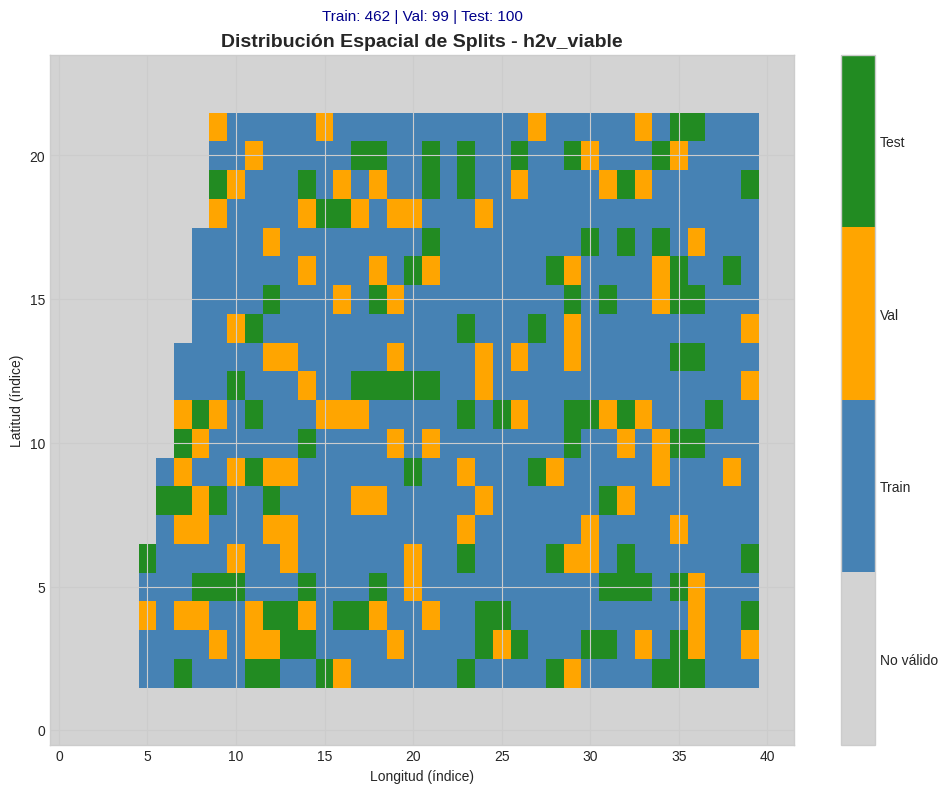

SPLITS ESPACIALES COMPLETADOS


In [20]:
if tensors_normalized is not None and CONFIG is not None:
    print("SPLITS ESPACIALES (TRAIN / VAL / TEST)")
    
    # Obtener parámetros de split
    train_ratio = CONFIG['train_ratio']
    val_ratio = CONFIG['val_ratio']
    test_ratio = CONFIG['test_ratio']
    random_seed = CONFIG['random_seed']
    
    # Verificar que sumen 1.0
    total_ratio = train_ratio + val_ratio + test_ratio
    if not np.isclose(total_ratio, 1.0):
        print(f"Ratios no suman 1.0: {total_ratio:.3f}")
        print(f" Ajustando ratios proporcionalmente...")
        train_ratio /= total_ratio
        val_ratio /= total_ratio
        test_ratio /= total_ratio
    
        print(f"\nConfiguración de splits:")
        print(f" Train: {train_ratio*100:.1f}%")
        print(f" Val: {val_ratio*100:.1f}%")
        print(f" Test: {test_ratio*100:.1f}%")
        print(f" Random seed: {random_seed}")
    
    # Usar escenario de referencia para crear splits
    ref_tensor = tensors_normalized[REFERENCE_SCENARIO]
    n_cells = ref_tensor['n_cells']
    
    print(f"\n Total de celdas: {n_cells}")
    
    # Crear índices para split
    indices = np.arange(n_cells)
    np.random.seed(random_seed)
    
    # Split en dos pasos: train vs (val+test), luego val vs test
    train_idx, test_val_idx = train_test_split(
        indices, 
        test_size=(val_ratio + test_ratio), 
        random_state=random_seed
    )
    
    # Split val vs test (proporción relativa)
    val_ratio_relative = val_ratio / (val_ratio + test_ratio)
    val_idx, test_idx = train_test_split(
        test_val_idx,
        test_size=(1 - val_ratio_relative),
        random_state=random_seed
    )
    
    print(f"\nSplits creados:")
    print(f" Train: {len(train_idx)} celdas ({len(train_idx)/n_cells*100:.1f}%)")
    print(f" Val: {len(val_idx)} celdas ({len(val_idx)/n_cells*100:.1f}%)")
    print(f" Test: {len(test_idx)} celdas ({len(test_idx)/n_cells*100:.1f}%)")
        
    # Aplicar splits a todos los escenarios
    splits = {}
    
    for scenario, tensor_data in tensors_normalized.items():
        X = tensor_data['X']
        
        splits[scenario] = {
            'X_train': X[train_idx],
            'X_val': X[val_idx],
            'X_test': X[test_idx],
            'train_idx': train_idx,
            'val_idx': val_idx,
            'test_idx': test_idx,
            'feature_names': tensor_data['feature_names'],
            'mask': tensor_data['mask'],
            'mask_name': tensor_data['mask_name']
        }
        
    # Visualizar distribución espacial de splits
    print(f"\nVisualizando distribución espacial...")
    
    # Crear mapa de splits
    split_map = np.full(selected_mask.shape, -1.0)  # -1 para celdas no seleccionadas
    
    # Obtener coordenadas planas de celdas válidas
    flat_indices = np.where(selected_mask.flatten())[0]
    
    # Asignar valores de split
    split_map.flat[flat_indices[train_idx]] = 0  # Train
    split_map.flat[flat_indices[val_idx]] = 1    # Val
    split_map.flat[flat_indices[test_idx]] = 2   # Test
    
    # Plotear
    fig, ax = plt.subplots(1, 1, figsize=(10, 8))
    
    # Colormap personalizado
    from matplotlib.colors import ListedColormap, BoundaryNorm
    colors = ['lightgray', 'steelblue', 'orange', 'forestgreen']
    cmap = ListedColormap(colors)
    bounds = [-1.5, -0.5, 0.5, 1.5, 2.5]
    norm = BoundaryNorm(bounds, cmap.N)
    
    im = ax.imshow(split_map, cmap=cmap, norm=norm, origin='lower', aspect='auto')
    
    # Colorbar con labels
    cbar = plt.colorbar(im, ax=ax, ticks=[-1, 0, 1, 2])
    cbar.ax.set_yticklabels(['No válido', 'Train', 'Val', 'Test'])
    
    ax.set_title(f'Distribución Espacial de Splits - {selected_mask_name}', 
                 fontsize=14, fontweight='bold')
    ax.set_xlabel('Longitud (índice)')
    ax.set_ylabel('Latitud (índice)')
    
    # Añadir conteo en el título
    title_prefix = f"Train: {len(train_idx)} | Val: {len(val_idx)} | Test: {len(test_idx)}"
    ax.text(0.5, 1.05, title_prefix, transform=ax.transAxes,
            ha='center', fontsize=11, color='darkblue')
    
    plt.tight_layout()
    
    # Guardar figura
    fig_path = PLOTS_DIR / f'splits_spatial_distribution_{MODE}.png'
    plt.savefig(fig_path, dpi=150, bbox_inches='tight')
    print(f" Figura guardada: {fig_path.name}")
    
    plt.show()
    
    print("SPLITS ESPACIALES COMPLETADOS")

else:
    print("No hay tensores normalizados o configuración disponible")
    splits = None

## Export de Tensores Procesados

In [21]:
# NUEVA CELDA - Agregar ANTES de crear el metadata
# Extraer coordenadas del dataset de referencia
lat_coords = ds_ref.lat.values
lon_coords = ds_ref.lon.values
grid_shape = selected_mask.shape  # (24, 42)

print(f"\n Información espacial:")
print(f" Grid shape: {grid_shape}")
print(f" Lat range: [{lat_coords.min():.4f}, {lat_coords.max():.4f}]")
print(f" Lon range: [{lon_coords.min():.4f}, {lon_coords.max():.4f}]")


 Información espacial:
 Grid shape: (24, 42)
 Lat range: [-33.3250, -32.1750]
 Lon range: [-71.9750, -69.9250]


In [22]:
if splits is not None and scalers is not None:
    print("EXPORT DE TENSORES PROCESADOS")
    
    # Crear directorio de output si no existe
    OUT_DIR.mkdir(parents=True, exist_ok=True)
    
    print(f"\nDirectorio de salida: {OUT_DIR}")
    
    # 1. Exportar splits por escenario
    print(f"\nExportando splits por escenario...")
    
    for scenario, split_data in splits.items():
        # Archivo para este escenario
        splits_file = OUT_DIR / f'tensors_{scenario}_splits_{MODE}.npz'
        
        # Guardar con compresión
        np.savez_compressed(
            splits_file,
            X_train=split_data['X_train'],
            X_val=split_data['X_val'],
            X_test=split_data['X_test'],
            train_idx=split_data['train_idx'],
            val_idx=split_data['val_idx'],
            test_idx=split_data['test_idx']
        )
        
        file_size = splits_file.stat().st_size / (1024**2)
        print(f" {scenario.upper()}: {splits_file.name} ({file_size:.2f} MB)")
        print(f" Train: {split_data['X_train'].shape}")
        print(f" Val: {split_data['X_val'].shape}")
        print(f" Test: {split_data['X_test'].shape}")
    
    # 2. Exportar scalers
    print(f"\nExportando scalers...")
    scalers_file = OUT_DIR / f'scalers_{MODE}.pkl'
    
    with open(scalers_file, 'wb') as f:
        pickle.dump(scalers, f)
    
    file_size = scalers_file.stat().st_size / 1024
    print(f" Scalers: {scalers_file.name} ({file_size:.2f} KB)")
    print(f" Tipos: {list(scalers.keys())}")
        
    # 3. Exportar metadata
    print(f"\nExportando metadata...")
    
    # Usar referencia para metadata común
    ref_split = splits[REFERENCE_SCENARIO]
    
    
    metadata = {
        'feature_names': ref_split['feature_names'],
        'n_features': len(ref_split['feature_names']),
        'mask': ref_split['mask'],
        'mask_name': ref_split['mask_name'],
        'spatial_info': {
            'lat': lat_coords,
            'lon': lon_coords,
            'grid_shape': grid_shape,
            'lat_min': float(lat_coords.min()),
            'lat_max': float(lat_coords.max()),
            'lon_min': float(lon_coords.min()),
            'lon_max': float(lon_coords.max())
        },
        # ⬇️ AGREGAR ESTO:
        'splits': {
            'train_idx': ref_split['train_idx'],
            'val_idx': ref_split['val_idx'],
            'test_idx': ref_split['test_idx']
        },
        # ⬆️
        'n_cells': {
            'train': len(ref_split['train_idx']),
            'val': len(ref_split['val_idx']),
            'test': len(ref_split['test_idx']),
            'total': len(ref_split['train_idx']) + len(ref_split['val_idx']) + len(ref_split['test_idx'])
        },
        'config': CONFIG,
        'var_normalization': VAR_NORMALIZATION,
        'scenarios': list(splits.keys()),
        'reference_scenario': REFERENCE_SCENARIO,
        'mode': MODE,
        # Scalers provenance (SIEMPRE X_BASE - normalización global)
        'scalers_source': 'X_BASE',
        'scalers_fit_mode': 'global_base',
        'x_base_shape': tuple(X_BASE.shape) if 'X_BASE' in globals() else None,
        'x_base_rows': int(X_BASE.shape[0]) if 'X_BASE' in globals() else None,
        'created_at': pd.Timestamp.now().isoformat()
    }
    
    metadata_file = OUT_DIR / f'metadata_{MODE}.pkl'
    
    with open(metadata_file, 'wb') as f:
        pickle.dump(metadata, f)
    
    file_size = metadata_file.stat().st_size / 1024
    print(f" Metadata: {metadata_file.name} ({file_size:.2f} KB)")
    
    # 4. Exportar feature names a CSV (para referencia fácil)
    print(f"\nExportando feature names a CSV...")
    
    # Crear DataFrame con información de features
    feature_info = []
    for i, fname in enumerate(ref_split['feature_names']):
        # Identificar tipo de scaler
        if '_decadal_' in fname:
            base_var = fname.split('_decadal_')[0]
        elif '_trend_' in fname:
            base_var = fname.split('_trend_')[0]
        elif fname[-5:].isdigit():
            parts = fname.split('_')
            base_var = '_'.join(parts[:-1])
        else:
            base_var = fname
        
        scaler_type = VAR_NORMALIZATION.get(base_var, 'standard')
        
        # Estadísticas del feature
        X_train = ref_split['X_train'][:, i]
        
        feature_info.append({
            'index': i,
            'feature_name': fname,
            'base_variable': base_var,
            'scaler_type': scaler_type if scaler_type else 'none',
            'train_mean': X_train.mean(),
            'train_std': X_train.std(),
            'train_min': X_train.min(),
            'train_max': X_train.max(),
            'train_n_nans': np.isnan(X_train).sum()
        })
    
    df_features = pd.DataFrame(feature_info)
    features_file = OUT_DIR / f'feature_names_{MODE}.csv'
    df_features.to_csv(features_file, index=False)
    
    print(f" Feature names: {features_file.name}")
    print(f" Features: {len(df_features)}")
    
    # 5. Resumen de archivos exportados
    print(" EXPORT COMPLETADO")
    
    print(f"\n Archivos generados en {OUT_DIR.name}/:")
    print(f"\n Tensores (splits):")
    for scenario in splits.keys():
        file_path = OUT_DIR / f'tensors_{scenario}_splits_{MODE}.npz'
        if file_path.exists():
            size_mb = file_path.stat().st_size / (1024**2)
    print(f" • {file_path.name} ({size_mb:.2f} MB)")
    
    print(f"\n Metadata y configuración:")
    for file_name in [f'scalers_{MODE}.pkl', f'metadata_{MODE}.pkl', f'feature_names_{MODE}.csv']:
        file_path = OUT_DIR / file_name
        if file_path.exists():
            if file_name.endswith('.pkl'):
                size_kb = file_path.stat().st_size / 1024
                print(f" • {file_name} ({size_kb:.2f} KB)")
            else:
                size_kb = file_path.stat().st_size / 1024
                print(f" • {file_name} ({size_kb:.2f} KB)")
    
    print(f"\n Dataset listo para entrenamiento de autoencoder!")
    
else:
    print(" No hay splits o scalers disponibles para exportar")
    print(" Ejecutar celdas anteriores primero.")

EXPORT DE TENSORES PROCESADOS

Directorio de salida: /home/aninotna/magister/tesis/justh2_pipeline/data/autoencoder_tensors

Exportando splits por escenario...
 SSP245: tensors_ssp245_splits_full.npz (0.10 MB)
 Train: (462, 47)
 Val: (99, 47)
 Test: (100, 47)
 SSP370: tensors_ssp370_splits_full.npz (0.10 MB)
 Train: (462, 47)
 Val: (99, 47)
 Test: (100, 47)
 SSP585: tensors_ssp585_splits_full.npz (0.10 MB)
 Train: (462, 47)
 Val: (99, 47)
 Test: (100, 47)

Exportando scalers...
 Scalers: scalers_full.pkl (3.51 KB)
 Tipos: ['standard', 'minmax', 'robust']

Exportando metadata...
 Metadata: metadata_full.pkl (9.65 KB)

Exportando feature names a CSV...
 Feature names: feature_names_full.csv
 Features: 47
 EXPORT COMPLETADO

 Archivos generados en autoencoder_tensors/:

 Tensores (splits):
 • tensors_ssp585_splits_full.npz (0.10 MB)

 Metadata y configuración:
 • scalers_full.pkl (3.51 KB)
 • metadata_full.pkl (9.65 KB)
 • feature_names_full.csv (4.70 KB)

 Dataset listo para entrenamient

## Resumen y Verificación

RESUMEN Y VERIFICACIÓN FINAL

PREPROCESAMIENTO COMPLETADO

Escenarios procesados: 3
   • SSP245
   • SSP370
   • SSP585

Dimensiones finales (ssp245):
   Train: (462, 47) (0.08 MB)
   Val: (99, 47) (0.02 MB)
   Test: (100, 47) (0.02 MB)

Normalización aplicada:
   • standard: 39 features
   • minmax: 5 features
   • robust: 1 features

Verificación de NaNs:
   Train: 0 (0.0000%)
   Val: 0 (0.0000%)
   Test: 0 (0.0000%)

Generando visualizaciones de verificación...
   Mostrando 9 features StandardScaler con mejor varianza (de 39 total)
   Gráfico de verificación: normalization_verification_full.png
   Gráfico de verificación: normalization_verification_full.png


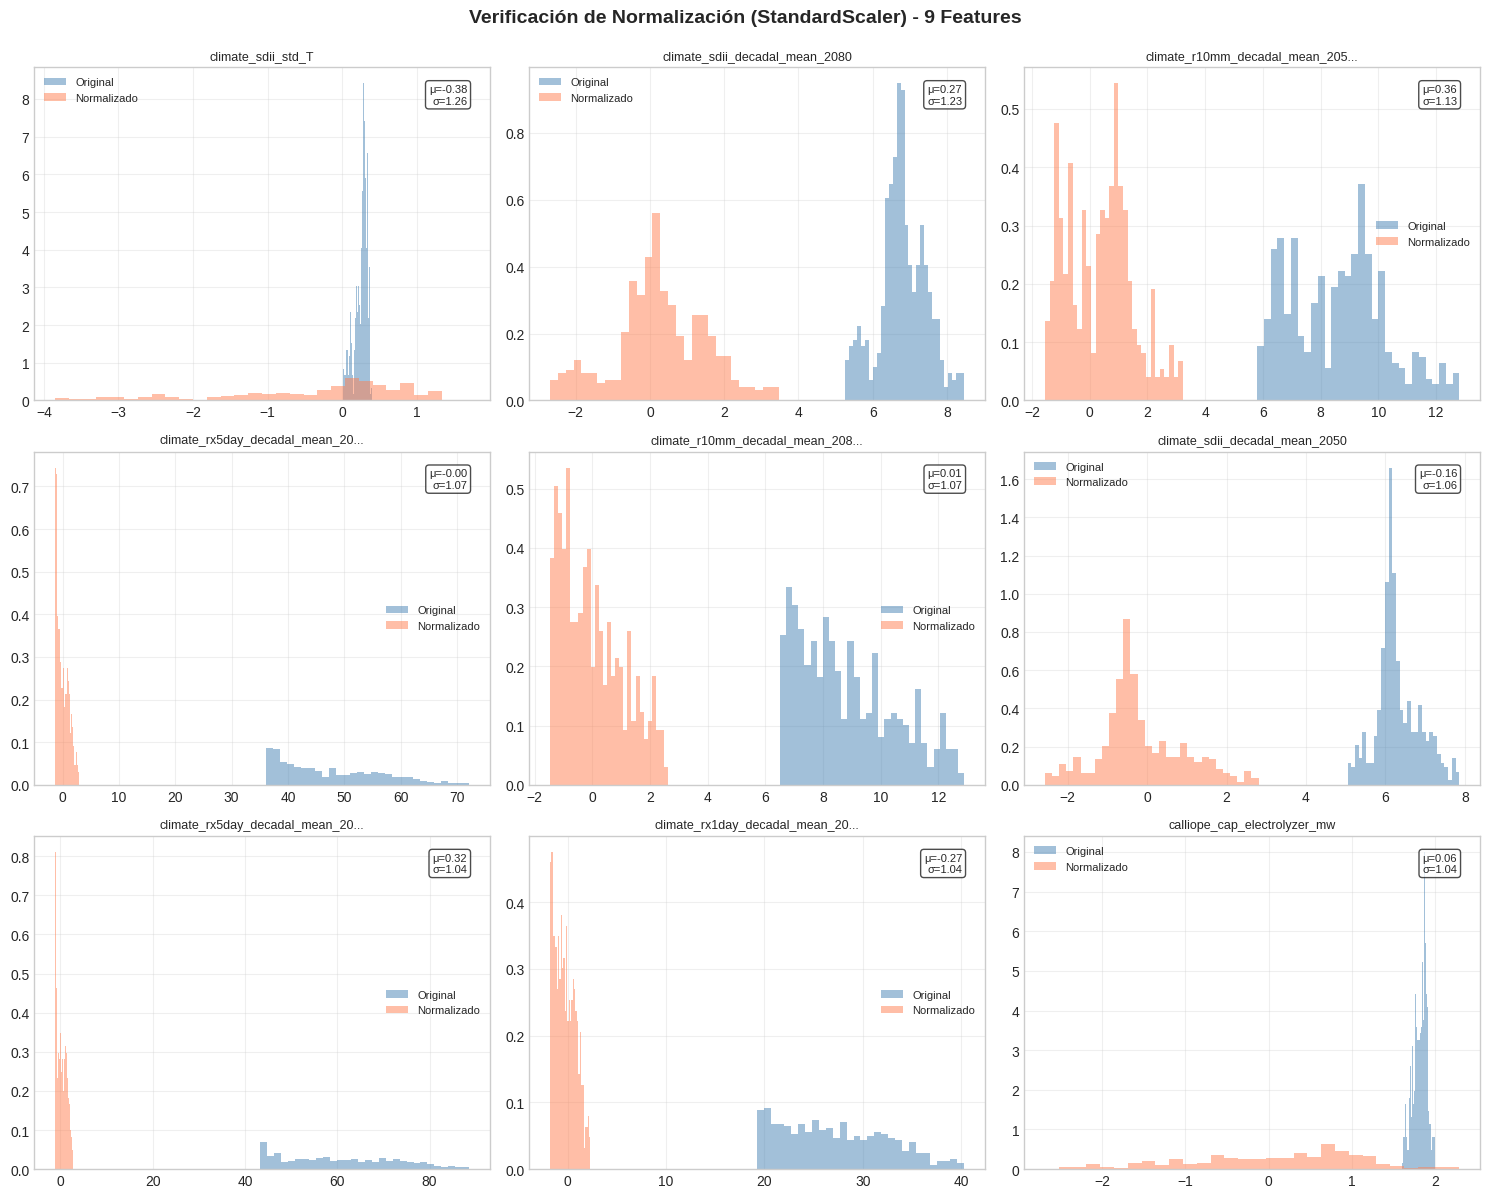


Top 10 features por variabilidad (std en train normalizado):
                         feature      std      mean
              climate_sdii_std_T 1.258203 -0.381235
  climate_sdii_decadal_mean_2080 1.233953  0.274204
 climate_r10mm_decadal_mean_2050 1.126542  0.362062
climate_rx5day_decadal_mean_2050 1.071256 -0.003357
 climate_r10mm_decadal_mean_2080 1.069489  0.009700
  climate_sdii_decadal_mean_2050 1.055434 -0.158344
climate_rx5day_decadal_mean_2080 1.044645  0.323670
climate_rx1day_decadal_mean_2080 1.039680 -0.266871
    calliope_cap_electrolyzer_mw 1.037807  0.057095
climate_rx1day_decadal_mean_2050 1.035093  0.581696

DATASET LISTO PARA AUTOENCODER

Próximos pasos:
   1. Datos cargados y preprocesados
   2. Normalización aplicada
   3. Splits espaciales creados
   4. Archivos exportados a autoencoder_tensors/

   5. Siguiente: Notebook 03 - Arquitectura del Autoencoder
      • Diseño encoder/decoder
      • Definición de latent space (5-10 dims)
      • Training loop con valid

In [23]:
if splits is not None and scalers is not None:
    print("RESUMEN Y VERIFICACIÓN FINAL")
    
    ref_split = splits[REFERENCE_SCENARIO]
    X_train = ref_split['X_train']
    X_val = ref_split['X_val']
    X_test = ref_split['X_test']
    feature_names = ref_split['feature_names']
    
    print(f"\nPREPROCESAMIENTO COMPLETADO")
    print(f"\nEscenarios procesados: {len(splits)}")
    for scenario in splits.keys():
        print(f"   • {scenario.upper()}")
    
    print(f"\nDimensiones finales ({REFERENCE_SCENARIO}):")
    print(f"   Train: {X_train.shape} ({X_train.nbytes/(1024**2):.2f} MB)")
    print(f"   Val: {X_val.shape} ({X_val.nbytes/(1024**2):.2f} MB)")
    print(f"   Test: {X_test.shape} ({X_test.nbytes/(1024**2):.2f} MB)")
    
    print(f"\nNormalización aplicada:")
    for stype, scaler_info in scalers.items():
        n_features = len(scaler_info['feature_indices'])
        print(f"   • {stype}: {n_features} features")
    
    print(f"\nVerificación de NaNs:")
    nan_train = np.isnan(X_train).sum()
    nan_val = np.isnan(X_val).sum()
    nan_test = np.isnan(X_test).sum()
    print(f"   Train: {nan_train} ({nan_train/X_train.size*100:.4f}%)")
    print(f"   Val: {nan_val} ({nan_val/X_val.size*100:.4f}%)")
    print(f"   Test: {nan_test} ({nan_test/X_test.size*100:.4f}%)")
    
    print(f"\nGenerando visualizaciones de verificación...")
    
    if 'standard' in scalers:
        std_all_indices = scalers['standard']['feature_indices']
        
        X_train_original = tensors_normalized[REFERENCE_SCENARIO]['X_original'][ref_split['train_idx']]
        
        std_variances = []
        for idx in std_all_indices:
            var = X_train[:, idx].std()
            std_variances.append((idx, var, feature_names[idx]))
        
        std_variances_sorted = sorted(std_variances, key=lambda x: x[1], reverse=True)
        
        std_indices = [item[0] for item in std_variances_sorted[:9]]
        std_names = [item[2] for item in std_variances_sorted[:9]]
        
        print(f"   Mostrando 9 features StandardScaler con mejor varianza (de {len(std_all_indices)} total)")
        
        fig, axes = plt.subplots(3, 3, figsize=(15, 12))
        axes = axes.flatten()
        
        for i, (idx, name) in enumerate(zip(std_indices, std_names)):
            ax = axes[i]
            
            data_original = X_train_original[:, idx]
            data_norm = X_train[:, idx]
            
            range_orig = data_original.max() - data_original.min()
            range_norm = data_norm.max() - data_norm.min()
            
            bins_orig = min(30, max(5, int(range_orig / (range_orig/30 + 1e-10))))
            bins_norm = min(30, max(5, int(range_norm / (range_norm/30 + 1e-10))))
            
            if range_orig < 1e-6:
                bins_orig = 'auto'
            if range_norm < 1e-6:
                bins_norm = 'auto'
            
            try:
                ax.hist(data_original, bins=bins_orig, alpha=0.5, 
                       color='steelblue', label='Original', density=True)
                
                ax.hist(data_norm, bins=bins_norm, alpha=0.5, 
                       color='coral', label='Normalizado', density=True)
            except ValueError as e:
                ax.text(0.5, 0.5, f'Datos constantes\no rango muy pequeño\n(std={data_norm.std():.2e})',
                       transform=ax.transAxes, ha='center', va='center',
                       fontsize=9, bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))
            
            short_name = name[:30] + '...' if len(name) > 30 else name
            ax.set_title(short_name, fontsize=9)
            ax.legend(fontsize=8)
            ax.grid(True, alpha=0.3)
            
            mu_norm = data_norm.mean()
            sigma_norm = data_norm.std()
            ax.text(0.95, 0.95, f'μ={mu_norm:.2f}\nσ={sigma_norm:.2f}',
                   transform=ax.transAxes, va='top', ha='right',
                   fontsize=8, bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
        
        plt.suptitle('Verificación de Normalización (StandardScaler) - 9 Features', 
                    fontsize=14, fontweight='bold', y=0.995)
        plt.tight_layout()
        
        fig_path = PLOTS_DIR / f'normalization_verification_{MODE}.png'
        plt.savefig(fig_path, dpi=150, bbox_inches='tight')
        print(f"   Gráfico de verificación: {fig_path.name}")
        
        plt.show()
    
    print(f"\nTop 10 features por variabilidad (std en train normalizado):")
    
    feature_stds = []
    for i, fname in enumerate(feature_names):
        feature_stds.append({
            'feature': fname,
            'std': X_train[:, i].std(),
            'mean': X_train[:, i].mean()
        })
    
    df_stds = pd.DataFrame(feature_stds).sort_values('std', ascending=False)
    print(df_stds.head(10).to_string(index=False))
    
    print(f"\nDATASET LISTO PARA AUTOENCODER")
    print(f"\nPróximos pasos:")
    print(f"   1. Datos cargados y preprocesados")
    print(f"   2. Normalización aplicada")
    print(f"   3. Splits espaciales creados")
    print(f"   4. Archivos exportados a {OUT_DIR.name}/")
    print(f"\n   5. Siguiente: Notebook 03 - Arquitectura del Autoencoder")
    print(f"      • Diseño encoder/decoder")
    print(f"      • Definición de latent space (5-10 dims)")
    print(f"      • Training loop con validación")
    
else:
    print("RESUMEN DE PREPROCESAMIENTO")
    print("\nNotebook en construcción...")
    print("\nCompletado hasta ahora:")
    print("   1. Carga de datasets imputados")
    print("   2. Definición de máscaras espaciales")
    print("   3. Agregación de variables temporales")
    print("   4. Creación de tensores con máscara aplicada")
    print("\nPendiente:")
    print("   5. Normalización de features")
    print("   6. Splits espaciales train/val/test")
    print("   7. Export de tensores procesados")
    print("   8. Visualizaciones de verificación")

## Verificación Especial: PV Capacity Factor

**Objetivo:** Verificar que `calliope_cf_mean` está correctamente normalizado en [0,1].

**Por qué es importante:**
- PV CF es una fracción física que debe estar entre 0 y 1
- Usa MinMaxScaler (no StandardScaler) porque ya está en ese rango
- Valores fuera de [0,1] indicarían un problema en los datos o la normalización

VERIFICACIÓN: PV Capacity Factor (calliope_cf_mean)

Features de PV CF encontrados: 1
   • calliope_cf_mean

1. DATOS ORIGINALES (antes de normalización)

SSP245:

   calliope_cf_mean:
      Rango: [0.179785, 0.252648]
      Media: 0.224626
      P01-P99: [0.191549, 0.249026]
      Valores dentro de [0,1]

SSP370:

   calliope_cf_mean:
      Rango: [0.179325, 0.252285]
      Media: 0.224040
      P01-P99: [0.190666, 0.248771]
      Valores dentro de [0,1]

SSP585:

   calliope_cf_mean:
      Rango: [0.181844, 0.254726]
      Media: 0.226746
      P01-P99: [0.193803, 0.251249]
      Valores dentro de [0,1]

2. DATOS NORMALIZADOS (después de MinMaxScaler)

SSP245:

   calliope_cf_mean:
      Rango: [0.179785, 0.252648]
      Media: 0.224626
      MinMaxScaler preservó rango [0,1]

SSP370:

   calliope_cf_mean:
      Rango: [0.179325, 0.252285]
      Media: 0.224040
      MinMaxScaler preservó rango [0,1]

SSP585:

   calliope_cf_mean:
      Rango: [0.181844, 0.254726]
      Media: 0.2267

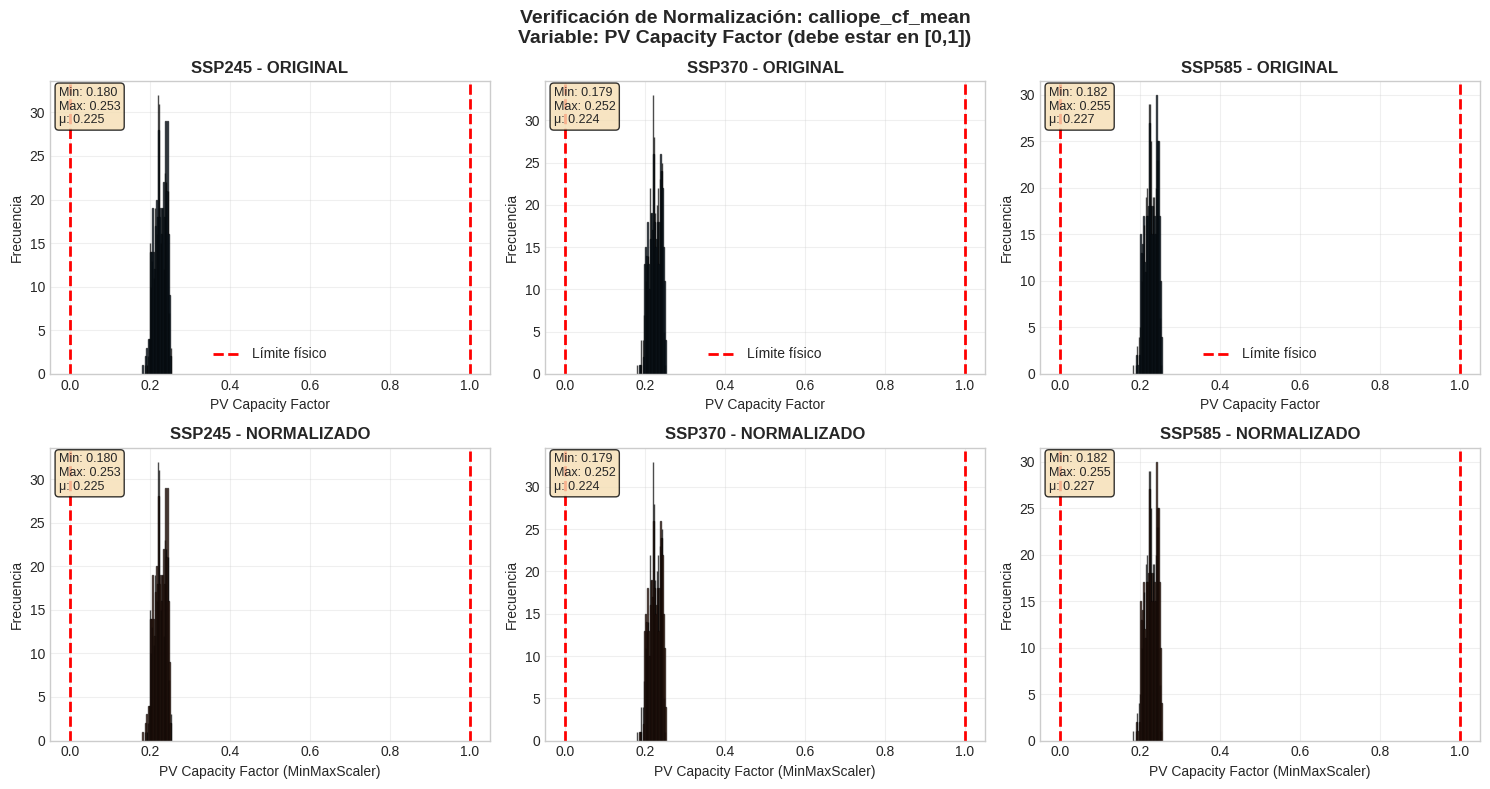


VERIFICACIÓN DE PV CF COMPLETADA

TODO CORRECTO:
   • Valores de PV CF en rango [0,1]
   • MinMaxScaler preserva el rango
   • Datos listos para autoencoder


In [24]:
if tensors_normalized is not None and scalers is not None:
    print("VERIFICACIÓN: PV Capacity Factor (calliope_cf_mean)")
    
    ref_tensor = tensors_normalized[REFERENCE_SCENARIO]
    feature_names = ref_tensor['feature_names']
    
    pv_cf_features = [f for f in feature_names if 'calliope_cf_mean' in f]
    
    if len(pv_cf_features) == 0:
        print("\nNo se encontraron features de calliope_cf_mean")
        print("   Esto es normal si la variable es estática (sin dimensión temporal)")
        
        if 'calliope_cf_mean' in feature_names:
            pv_cf_features = ['calliope_cf_mean']
    
    print(f"\nFeatures de PV CF encontrados: {len(pv_cf_features)}")
    for feat in pv_cf_features[:5]:
        print(f"   • {feat}")
    if len(pv_cf_features) > 5:
        print(f"   ... y {len(pv_cf_features) - 5} más")
    
    print("\n1. DATOS ORIGINALES (antes de normalización)")
    
    for scenario in SCENARIOS:
        X_original = tensors_normalized[scenario]['X_original']
        
        print(f"\n{scenario.upper()}:")
        
        for feat in pv_cf_features[:3]:
            feat_idx = feature_names.index(feat)
            values = X_original[:, feat_idx]
            values_valid = values[~np.isnan(values)]
            
            if len(values_valid) > 0:
                print(f"\n   {feat[:50]}:")
                print(f"      Rango: [{values_valid.min():.6f}, {values_valid.max():.6f}]")
                print(f"      Media: {values_valid.mean():.6f}")
                print(f"      P01-P99: [{np.percentile(values_valid, 1):.6f}, {np.percentile(values_valid, 99):.6f}]")
                
                if values_valid.min() < 0 or values_valid.max() > 1:
                    print(f"      PROBLEMA: Valores fuera de [0,1]!")
                    n_below_0 = np.sum(values_valid < 0)
                    n_above_1 = np.sum(values_valid > 1)
                    if n_below_0 > 0:
                        print(f"         Valores < 0: {n_below_0} ({n_below_0/len(values_valid)*100:.2f}%)")
                    if n_above_1 > 0:
                        print(f"         Valores > 1: {n_above_1} ({n_above_1/len(values_valid)*100:.2f}%)")
                else:
                    print(f"      Valores dentro de [0,1]")
    
    print("\n2. DATOS NORMALIZADOS (después de MinMaxScaler)")
    
    for scenario in SCENARIOS:
        X_normalized = tensors_normalized[scenario]['X']
        
        print(f"\n{scenario.upper()}:")
        
        for feat in pv_cf_features[:3]:
            feat_idx = feature_names.index(feat)
            values = X_normalized[:, feat_idx]
            values_valid = values[~np.isnan(values)]
            
            if len(values_valid) > 0:
                print(f"\n   {feat[:50]}:")
                print(f"      Rango: [{values_valid.min():.6f}, {values_valid.max():.6f}]")
                print(f"      Media: {values_valid.mean():.6f}")
                
                if values_valid.min() < -0.01 or values_valid.max() > 1.01:
                    print(f"      ADVERTENCIA: MinMaxScaler produjo valores fuera de [0,1]")
                else:
                    print(f"      MinMaxScaler preservó rango [0,1]")
    
    print("\n3. VISUALIZACIÓN COMPARATIVA")
    
    if len(pv_cf_features) > 0:
        feat_to_plot = pv_cf_features[0]
        feat_idx = feature_names.index(feat_to_plot)
        
        fig, axes = plt.subplots(2, 3, figsize=(15, 8))
        
        for i, scenario in enumerate(SCENARIOS):
            ax_orig = axes[0, i]
            X_orig = tensors_normalized[scenario]['X_original'][:, feat_idx]
            X_orig_valid = X_orig[~np.isnan(X_orig)]
            
            ax_orig.hist(X_orig_valid, bins=50, alpha=0.7, color='steelblue', edgecolor='black')
            ax_orig.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Límite físico')
            ax_orig.axvline(x=1, color='red', linestyle='--', linewidth=2)
            ax_orig.set_title(f'{scenario.upper()} - ORIGINAL', fontweight='bold')
            ax_orig.set_xlabel('PV Capacity Factor')
            ax_orig.set_ylabel('Frecuencia')
            ax_orig.legend()
            ax_orig.grid(True, alpha=0.3)
            
            stats_text = f'Min: {X_orig_valid.min():.3f}\nMax: {X_orig_valid.max():.3f}\nμ: {X_orig_valid.mean():.3f}'
            ax_orig.text(0.02, 0.98, stats_text, transform=ax_orig.transAxes,
                        verticalalignment='top', fontsize=9,
                        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
            
            ax_norm = axes[1, i]
            X_norm = tensors_normalized[scenario]['X'][:, feat_idx]
            X_norm_valid = X_norm[~np.isnan(X_norm)]
            
            ax_norm.hist(X_norm_valid, bins=50, alpha=0.7, color='coral', edgecolor='black')
            ax_norm.axvline(x=0, color='red', linestyle='--', linewidth=2)
            ax_norm.axvline(x=1, color='red', linestyle='--', linewidth=2)
            ax_norm.set_title(f'{scenario.upper()} - NORMALIZADO', fontweight='bold')
            ax_norm.set_xlabel('PV Capacity Factor (MinMaxScaler)')
            ax_norm.set_ylabel('Frecuencia')
            ax_norm.grid(True, alpha=0.3)
            
            stats_text = f'Min: {X_norm_valid.min():.3f}\nMax: {X_norm_valid.max():.3f}\nμ: {X_norm_valid.mean():.3f}'
            ax_norm.text(0.02, 0.98, stats_text, transform=ax_norm.transAxes,
                        verticalalignment='top', fontsize=9,
                        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
        
        plt.suptitle(f'Verificación de Normalización: {feat_to_plot}\n'
                    f'Variable: PV Capacity Factor (debe estar en [0,1])',
                    fontsize=14, fontweight='bold')
        plt.tight_layout()
        
        fig_path = PLOTS_DIR / f'pv_cf_normalization_check_{MODE}.png'
        plt.savefig(fig_path, dpi=150, bbox_inches='tight')
        print(f"\nGráfico guardado: {fig_path.name}")
        
        plt.show()
    
    print("\nVERIFICACIÓN DE PV CF COMPLETADA")
    
    has_issues = False
    
    for scenario in SCENARIOS:
        X_orig = tensors_normalized[scenario]['X_original']
        for feat in pv_cf_features:
            feat_idx = feature_names.index(feat)
            values = X_orig[:, feat_idx]
            values_valid = values[~np.isnan(values)]
            
            if len(values_valid) > 0:
                if values_valid.min() < 0 or values_valid.max() > 1:
                    has_issues = True
                    break
        if has_issues:
            break
    
    if has_issues:
        print("\nSE DETECTARON PROBLEMAS:")
        print("   • Algunos valores de PV CF están fuera de [0,1]")
        print("   • ACCIÓN REQUERIDA:")
        print("     1. Revisar datos originales en autoencoder_stack_{ssp}_test_imputed.nc")
        print("     2. Verificar imputación en notebook 01_explore_stack.ipynb")
        print("     3. Considerar clip a [0,1]: X = np.clip(X, 0, 1)")
    else:
        print("\nTODO CORRECTO:")
        print("   • Valores de PV CF en rango [0,1]")
        print("   • MinMaxScaler preserva el rango")
        print("   • Datos listos para autoencoder")
    
else:
    print("VERIFICACIÓN DE PV CF")
    print("\nNo se puede verificar:")
    print("   • tensors_normalized no disponible")
    print("   • Ejecutar celdas anteriores primero")

In [25]:
if 'X_BASE' in globals() and 'scalers' in globals():
    print("X_BASE existe:", X_BASE.shape)
    print("Scalers entrenados:")
    for stype in scalers.keys():
        n_features = len(scalers[stype]['feature_indices'])
        print(f"   • {stype}: {n_features} features")
    
    print("\nVerificación:")
    print(f"   X_BASE shape: {X_BASE.shape}")
    print(f"   Scalers ajustados sobre X_BASE")
else:
    print("Esta celda requiere que se hayan ejecutado las celdas anteriores")

X_BASE existe: (1983, 47)
Scalers entrenados:
   • standard: 39 features
   • minmax: 5 features
   • robust: 1 features

Verificación:
   X_BASE shape: (1983, 47)
   Scalers ajustados sobre X_BASE


## Exportar Datos ORIGINALES (Sin Normalizar)

** EJECUTAR SOLO DESPUÉS de haber ejecutado TODAS las celdas anteriores**

**Problema identificado en notebook 03b:**
- Las visualizaciones "ANTES" del autoencoder muestran datos **ya normalizados**
- Esto hace que algunas variables se vean cerca de 0 (ej: `calliope_cap_pv_mw` con StandardScaler)
- Necesitamos exportar también los datos **ORIGINALES** para visualizaciones correctas

**Solución:**
- Exportar `X_original` (antes de normalización) junto con `X` (normalizado)
- Esto permitirá comparaciones "raw vs reconstructed" en notebook 03b

**Archivos que se crearán:**
- `tensors_{scenario}_splits_{mode}_ORIGINAL.npz` con datos SIN normalizar

In [26]:
if tensors_normalized is not None:
    print(" EXPORTANDO DATOS ORIGINALES (SIN NORMALIZAR)")
        
    print(f"\nDirectorio de salida: {OUT_DIR}")
        
        # Exportar datos originales por escenario (ANTES de normalización)
    print(f"\n Exportando datos originales...")
        
    for scenario, tensor_data in tensors_normalized.items():
        # Obtener datos originales completos
        X_original_full = tensor_data['X_original']
        
        # Aplicar mismo split que los datos normalizados
        # (usar los índices guardados en splits[scenario])
        if scenario in splits:
            split_data = splits[scenario]
            train_idx = split_data['train_idx']
            val_idx = split_data['val_idx']
            test_idx = split_data['test_idx']
            
            # Crear splits de datos originales
            X_original_train = X_original_full[train_idx]
            X_original_val = X_original_full[val_idx]
            X_original_test = X_original_full[test_idx]
            
            # Guardar archivo con datos originales
            original_file = OUT_DIR / f'tensors_{scenario}_splits_{MODE}_ORIGINAL.npz'
            
            np.savez_compressed(
                original_file,
                X_train_original=X_original_train,
                X_val_original=X_original_val,
                X_test_original=X_original_test,
                train_idx=train_idx,
                val_idx=val_idx,
                test_idx=test_idx
            )
            
            file_size = original_file.stat().st_size / (1024**2)
            print(f"\n {scenario.upper()}: {original_file.name} ({file_size:.2f} MB)")
            print(f" Train original: {X_original_train.shape}")
            print(f" Val original: {X_original_val.shape}")
            print(f" Test original: {X_original_test.shape}")
            
            # Verificar rangos de algunas variables clave
            print(f"\n Rangos de variables clave (ORIGINALES):")
            
            # PV CF
            if 'calliope_cf_mean' in feature_names:
                idx = feature_names.index('calliope_cf_mean')
                cf_vals = X_original_full[:, idx]
                cf_valid = cf_vals[~np.isnan(cf_vals)]
                print(f" calliope_cf_mean: [{cf_valid.min():.4f}, {cf_valid.max():.4f}]")
            
            # LCOH
            if 'calliope_lcoh_usd_kg' in feature_names:
                idx = feature_names.index('calliope_lcoh_usd_kg')
                lcoh_vals = X_original_full[:, idx]
                lcoh_valid = lcoh_vals[~np.isnan(lcoh_vals)]
                print(f" calliope_lcoh_usd_kg: [{lcoh_valid.min():.4f}, {lcoh_valid.max():.4f}]")
            
            # PV Capacity (MW)
            if 'calliope_cap_pv_mw' in feature_names:
                idx = feature_names.index('calliope_cap_pv_mw')
                cap_vals = X_original_full[:, idx]
                cap_valid = cap_vals[~np.isnan(cap_vals)]
                print(f" calliope_cap_pv_mw: [{cap_valid.min():.4f}, {cap_valid.max():.4f}]")
            
            # H2 Production
            if 'calliope_h2_prod_ton' in feature_names:
                idx = feature_names.index('calliope_h2_prod_ton')
                h2_vals = X_original_full[:, idx]
                h2_valid = h2_vals[~np.isnan(h2_vals)]
                print(f" calliope_h2_prod_ton: [{h2_valid.min():.4f}, {h2_valid.max():.4f}]")
                    
                print(" DATOS ORIGINALES EXPORTADOS")
                    
                print(f"\n Archivos creados:")
                print(f" • tensors_{{scenario}}_splits_{{mode}}.npz → Datos NORMALIZADOS")
                print(f" • tensors_{{scenario}}_splits_{{mode}}_ORIGINAL.npz → Datos ORIGINALES (sin normalizar)")
                    
                print(f"\n USO en notebook 03b:")
                print(f" 1. Cargar datos ORIGINALES para visualizaciones 'ANTES'")
                print(f" 2. Cargar datos NORMALIZADOS para entrenar autoencoder")
                print(f" 3. Comparar reconstrucción con ORIGINALES (más interpretable)")
                    
                print(f"\n IMPORTANTE:")
                print(f" • Los datos ORIGINALES NO deben usarse para entrenar el autoencoder")
                print(f" • Solo sirven para visualizaciones y comparaciones")
                print(f" • El autoencoder SIEMPRE se entrena con datos NORMALIZADOS")
                    
    
else:
    print(" EXPORTACIÓN DE DATOS ORIGINALES")
    print("\nNo se puede exportar:")
    print(" • tensors_normalized no disponible")
    print(" • Ejecutar celdas anteriores primero")


 EXPORTANDO DATOS ORIGINALES (SIN NORMALIZAR)

Directorio de salida: /home/aninotna/magister/tesis/justh2_pipeline/data/autoencoder_tensors

 Exportando datos originales...

 SSP245: tensors_ssp245_splits_full_ORIGINAL.npz (0.10 MB)
 Train original: (462, 47)
 Val original: (99, 47)
 Test original: (100, 47)

 Rangos de variables clave (ORIGINALES):
 calliope_cf_mean: [0.1798, 0.2526]

 SSP370: tensors_ssp370_splits_full_ORIGINAL.npz (0.10 MB)
 Train original: (462, 47)
 Val original: (99, 47)
 Test original: (100, 47)

 Rangos de variables clave (ORIGINALES):
 calliope_cf_mean: [0.1793, 0.2523]

 SSP585: tensors_ssp585_splits_full_ORIGINAL.npz (0.10 MB)
 Train original: (462, 47)
 Val original: (99, 47)
 Test original: (100, 47)

 Rangos de variables clave (ORIGINALES):
 calliope_cf_mean: [0.1818, 0.2547]
